### Preprocessing

This is the first step of our BioProv project. We are going to download the necessary data using a **Program**, and once we have the metadata table from such data, we are going to import that as a **Project**.

In [5]:
import bioprov as bp

In [6]:
ncbi_dl = bp.Program("ncbi-genome-download")

params = [
    bp.Parameter("-F", "fasta,assembly-report"),
    bp.Parameter("-s", "genbank"),
    bp.Parameter("-A", "data/genomes.txt"),
    bp.Parameter("-o", "data/"),
    bp.Parameter("-m", "data/metadata.tsv"),
    bp.Parameter("bacteria")
]

for param in params:
    ncbi_dl.add_parameter(param)

In [7]:
ncbi_dl.run()

Running program 'ncbi-genome-download'.
Command is:
/Users/vini/anaconda3/envs/bp-use-case/bin/ncbi-genome-download \ 
	-F fasta,assembly-report \ 
	-s genbank \ 
	-A data/genomes.txt \ 
	-o data/ \ 
	-m data/metadata.tsv \ 
	bacteria




stdout:




stderr:




Run of Program 'ncbi-genome-download' with 6 parameter(s).
Started at Tue Jan  5 17:40:50 2021.
Ended at Tue Jan  5 17:42:05 2021.
Status is finished.

The resulting `metadata.tsv` table contains metadata about the files that were just downloaded. We can therefore use it to import our project. However, the table contains duplicated rows (a limitation of the `ncbi-genome-download` package. We are going to run a simple Linux command to get rid of those:

In [8]:
metadata_table = bp.File("data/metadata.tsv", tag="metadata")

sort = bp.Program("sort")

params = [
    bp.Parameter("-t", "' '"),
    bp.Parameter("-k", "1,1"),
    bp.Parameter("-u", str(metadata_table)),
    bp.Parameter("-r"),
    bp.Parameter("-o", str(metadata_table))
]

for param in params:
    sort.add_parameter(param)
    
sort.run()

Running program 'sort'.
Command is:
/usr/bin/sort \ 
	-t ' \ 
	' -k \ 
	1,1 -u \ 
	/Users/vini/Bio/BioProv/use-case/data/metadata.tsv -r \ 
	-o /Users/vini/Bio/BioProv/use-case/data/metadata.tsv 




stdout:




stderr:




Run of Program 'sort' with 5 parameter(s).
Started at Tue Jan  5 17:42:30 2021.
Ended at Tue Jan  5 17:42:30 2021.
Status is finished.

A second aspect of the `ncbi-genome-download` package is that it downloads the files in a compressed format. We are going to create a program to decompress those files and another one to modify the metadata table accordingly. Another aspect of the metadata table that we want to improve is renaming the `local_filename` column as `genome_assembly`, which helps describe the contents of the file.

In [10]:
gunzip = bp.Program("gunzip")

gunzip.add_parameter(bp.Parameter("data/genbank/bacteria/*/*"))

gunzip.run(suppress_stdout=True)

Running program 'gunzip'.
Command is:
/usr/bin/gunzip data/genbank/bacteria/*/*




stdout:




stderr:

gunzip: data/genbank/bacteria/GCA_000007925.1/GCA_000007925.1_ASM792v1_assembly_report.txt: unknown suffix -- ignored
gunzip: data/genbank/bacteria/GCA_000007925.1/GCA_000007925.1_ASM792v1_genomic.fna: unknown suffix -- ignored
gunzip: data/genbank/bacteria/GCA_000007925.1/GCA_000007925.1_ASM792v1_genomic.fna already exists -- skipping
gunzip: data/genbank/bacteria/GCA_000007925.1/GCA_000007925.1_ASM792v1_genomic_genes.fna: unknown suffix -- ignored
gunzip: data/genbank/bacteria/GCA_000007925.1/GCA_000007925.1_ASM792v1_genomic_proteins.faa: unknown suffix -- ignored
gunzip: data/genbank/bacteria/GCA_000007925.1/MD5SUMS: unknown suffix -- ignored
gunzip: data/genbank/bacteria/GCA_000010065.1/GCA_000010065.1_ASM1006v1_assembly_report.txt: unknown suffix -- ignored
gunzip: data/genbank/bacteria/GCA_000010065.1/GCA_000010065.1_ASM1006v1_genomic.fna: unknown suffix -- ignored
gunzip: data/genbank/bacteria/GCA_000010065.1/GCA_000010065.1_ASM1006v1_genomic.fna already e

Run of Program 'gunzip' with 1 parameter(s).
Started at Tue Jan  5 17:42:52 2021.
Ended at Tue Jan  5 17:42:52 2021.
Status is finished.

In [21]:
sed_gz = bp.Program("sed")

params = [
    bp.Parameter("-i", ".bkp"),
    bp.Parameter("'s/.gz//g'"),
    bp.Parameter(str(metadata_table)),
]

for param in params:
    sed_gz.add_parameter(param)
    
sed_gz.run()

sed_column = bp.Program("sed")

params = [
    bp.Parameter("-i", "bkp"),
    bp.Parameter("'s/local_filename/genome_assembly/g'"),
    bp.Parameter(str(metadata_table)),
]

for param in params:
    sed_column.add_parameter(param)
    
sed_column.run()

Running program 'sed'.
Command is:
/usr/bin/sed \ 
	-i bkp \ 
	's/.gz//g' /Users/vini/Bio/BioProv/use-case/data/metadata.tsv 
Running program 'sed'.
Command is:
/usr/bin/sed \ 
	-i bkp \ 
	's/local_filename/genome_assembly/g' /Users/vini/Bio/BioProv/use-case/data/metadata.tsv 




stdout:




stderr:




stdout:




stderr:




Run of Program 'sed' with 3 parameter(s).
Started at Tue Jan  5 17:48:15 2021.
Ended at Tue Jan  5 17:48:15 2021.
Status is finished.

We can now import the file normally. Since we are creating our project, we can associate the previous programs with it.

In [22]:
proj = bp.read_csv("data/metadata.tsv",
                   sep="\t",
                   sequencefile_cols="genome_assembly",
                   import_data=True,
                   tag="bp-use-case")

proj.add_programs((ncbi_dl, sort, gunzip, sed_gz, sed_column))

We can also associate the `assembly-report` files downloaded along with the genome sequences:

In [23]:
for k, sample in proj.items():
    sample.add_files(
        bp.File(str(sample.files["genome_assembly"].path).replace("_genomic.fna", "_assembly_report.txt"),
                tag="assembly_report"))

In [24]:
for k, sample in proj.items():
    sample.attributes["genus"] = sample.attributes["organism_name"].split()[0]

In [25]:
proj.update_db()

Interromper notebook aqui.

If we inspect the samples and files in our project, we can note that metadata associated with each sequence has been imported, such as GC content and total number of base pairs. The latter is particularly useful when comparing whole-genome sequences:

In [144]:
proj.samples

{'GCA_003990665.2': Sample 'GCA_003990665.2' with 2 file(s).,
 'GCA_003149585.1': Sample 'GCA_003149585.1' with 2 file(s).,
 'GCA_002252705.1': Sample 'GCA_002252705.1' with 2 file(s).,
 'GCA_001182765.1': Sample 'GCA_001182765.1' with 2 file(s).,
 'GCA_000760375.1': Sample 'GCA_000760375.1' with 2 file(s).,
 'GCA_000316515.1': Sample 'GCA_000316515.1' with 2 file(s).,
 'GCA_000153045.1': Sample 'GCA_000153045.1' with 2 file(s).,
 'GCA_000063525.1': Sample 'GCA_000063525.1' with 2 file(s).,
 'GCA_000063505.1': Sample 'GCA_000063505.1' with 2 file(s).,
 'GCA_000019485.1': Sample 'GCA_000019485.1' with 2 file(s).,
 'GCA_000012625.1': Sample 'GCA_000012625.1' with 2 file(s).,
 'GCA_000011485.1': Sample 'GCA_000011485.1' with 2 file(s).,
 'GCA_000010065.1': Sample 'GCA_000010065.1' with 2 file(s).,
 'GCA_000007925.1': Sample 'GCA_000007925.1' with 2 file(s).}

In [145]:
proj["GCA_000007925.1"].files

{'genome_assembly': /Users/vini/Bio/BioProv/use-case/data/genbank/bacteria/GCA_000007925.1/GCA_000007925.1_ASM792v1_genomic.fna,
 'assembly_report': /Users/vini/Bio/BioProv/use-case/data/genbank/bacteria/GCA_000007925.1/GCA_000007925.1_ASM792v1_assembly_report.txt}

In [146]:
proj["GCA_000007925.1"].files["genome_assembly"].total_bps

1751080

In [147]:
proj["GCA_000007925.1"].files["genome_assembly"].GC

0.36442

Interromper notebook aqui.

/Users/vini/anaconda3/envs/bp-use-case/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y, hue. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:>

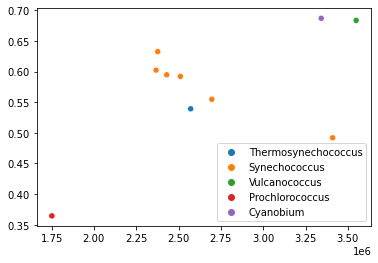

In [149]:
x = [sample.files["genome_assembly"].total_bps for k, sample in proj.items()]
y = [sample.files["genome_assembly"].GC for k, sample in proj.items()]
z = [sample.attributes["genus"] for k, sample in proj.items()]
sns.scatterplot(x, y, z)

In [154]:
[(sample, sample.files["genome_assembly"].total_bps, sample.files["genome_assembly"].GC) 
  for k, sample in proj.items() if sample.attributes["genus"] == "Prochlorococcus"]

[(Sample 'GCA_000760375.1' with 2 file(s)., 1754053, 0.36438),
 (Sample 'GCA_000011485.1' with 2 file(s)., 2410873, nan),
 (Sample 'GCA_000007925.1' with 2 file(s)., 1751080, 0.36442)]

In [161]:
proj["GCA_000011485.1"].files["genome_assembly"].__dict__

{'path': PosixPath('/Users/vini/Bio/BioProv/use-case/data/genbank/bacteria/GCA_000011485.1/GCA_000011485.1_ASM1148v1_genomic.fna'),
 'name': 'GCA_000011485.1_ASM1148v1_genomic',
 'basename': 'GCA_000011485.1_ASM1148v1_genomic.fna',
 'directory': PosixPath('/Users/vini/Bio/BioProv/use-case/data/genbank/bacteria/GCA_000011485.1'),
 'extension': '.fna',
 'tag': 'genome_assembly',
 'attributes': {},
 '_exists': True,
 '_size': '2.3 MB',
 'raw_size': 2441069,
 '_sha1': '1464e15a23f879051c9fe9727ddd97e28f56c731',
 '_entity': None,
 'format': 'fasta',
 'records': {'BX548175.1': SeqRecord(seq=Seq('TTCCACGATTTCCTCAAGCCCTACTACTACGATTCTTTTAATTTCTTTTAATAA...ATT'), id='BX548175.1', name='BX548175.1', description='BX548175.1 Prochlorococcus marinus MIT9313 complete genome', dbxrefs=[])},
 '_generator': <Bio.SeqIO.FastaIO.FastaIterator at 0x1386d0e20>,
 '_seqstats': SeqStats(number_seqs=1, total_bps=2410873, mean_bp=2410873.0, min_bp=2410873, max_bp=2410873, N50=2410873, GC=nan),
 '_parser': 'seq',
 

In [26]:
prov = bp.BioProvDocument(proj)

In [27]:
prov.dot.write_pdf("graphs/processing.pdf")

In [167]:
bp.load_project("bp-use-case")

Project 'bp-use-case' with 14 samples